Class distribution before resampling:
Normal (0): 6627
Attack (1): 373

Class distribution after SMOTE:
Normal (0): 6627
Attack (1): 6627
SMOTE Time: 0.0155 seconds

Class distribution after ADASYN:
Normal (0): 6627
Attack (1): 6712
ADASYN Time: 0.0803 seconds


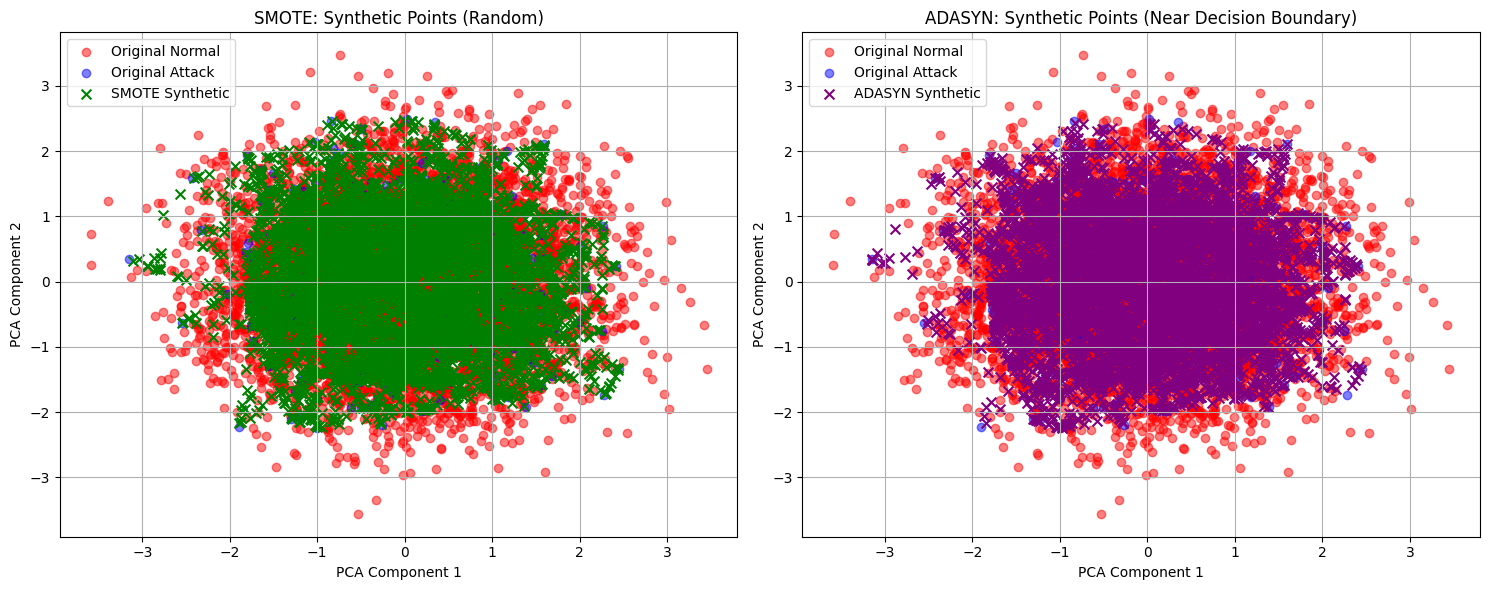


=== Summary ===
SMOTE Time: 0.0155 seconds
ADASYN Time: 0.0803 seconds

F1-Scores:
Original: 0.0000
After SMOTE: 0.0828
After ADASYN: 0.0842


In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE, ADASYN

# Step 1: Simulate a subset of KDD Cup 99 (binary classification)
np.random.seed(42)
n_samples = 10000
n_features = 10
X = np.random.rand(n_samples, n_features)
y = np.random.randint(0, 2, size=n_samples)
y[:int(0.9 * n_samples)] = 0  # 90% normal, 10% attack

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Class distribution before resampling:")
print(f"Normal (0): {np.sum(y_train == 0)}")
print(f"Attack (1): {np.sum(y_train == 1)}")

# Step 2: Apply SMOTE
start_time = time.time()
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
smote_time = time.time() - start_time

print("\nClass distribution after SMOTE:")
print(f"Normal (0): {np.sum(y_smote == 0)}")
print(f"Attack (1): {np.sum(y_smote == 1)}")
print(f"SMOTE Time: {smote_time:.4f} seconds")

# Step 3: Apply ADASYN
start_time = time.time()
adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train, y_train)
adasyn_time = time.time() - start_time

print("\nClass distribution after ADASYN:")
print(f"Normal (0): {np.sum(y_adasyn == 0)}")
print(f"Attack (1): {np.sum(y_adasyn == 1)}")
print(f"ADASYN Time: {adasyn_time:.4f} seconds")

# Step 4: Plot synthetic points
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_smote_2d = pca.transform(X_smote)
X_adasyn_2d = pca.transform(X_adasyn)

original_majority = X_train_2d[y_train == 0]
original_minority = X_train_2d[y_train == 1]
smote_synthetic = X_smote_2d[y_smote == 1][len(original_minority):]
adasyn_synthetic = X_adasyn_2d[y_adasyn == 1][len(original_minority):]

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.scatter(original_majority[:, 0], original_majority[:, 1], color='red', label='Original Normal', alpha=0.5)
plt.scatter(original_minority[:, 0], original_minority[:, 1], color='blue', label='Original Attack', alpha=0.5)
plt.scatter(smote_synthetic[:, 0], smote_synthetic[:, 1], color='green', marker='x', s=50, label='SMOTE Synthetic')
plt.title("SMOTE: Synthetic Points (Random)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(original_majority[:, 0], original_majority[:, 1], color='red', label='Original Normal', alpha=0.5)
plt.scatter(original_minority[:, 0], original_minority[:, 1], color='blue', label='Original Attack', alpha=0.5)
plt.scatter(adasyn_synthetic[:, 0], adasyn_synthetic[:, 1], color='purple', marker='x', s=50, label='ADASYN Synthetic')
plt.title("ADASYN: Synthetic Points (Near Decision Boundary)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 5: Measure F1-score before and after
# Original data
lr_original = LogisticRegression(max_iter=1000, random_state=42)
lr_original.fit(X_train, y_train)
y_pred_original = lr_original.predict(X_test)
f1_original = f1_score(y_test, y_pred_original)

# SMOTE data
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_smote, y_smote)
y_pred_smote = lr_smote.predict(X_test)
f1_smote = f1_score(y_test, y_pred_smote)

# ADASYN data
lr_adasyn = LogisticRegression(max_iter=1000, random_state=42)
lr_adasyn.fit(X_adasyn, y_adasyn)
y_pred_adasyn = lr_adasyn.predict(X_test)
f1_adasyn = f1_score(y_test, y_pred_adasyn)

print("\n=== Summary ===")
print(f"SMOTE Time: {smote_time:.4f} seconds")
print(f"ADASYN Time: {adasyn_time:.4f} seconds")
print("\nF1-Scores:")
print(f"Original: {f1_original:.4f}")
print(f"After SMOTE: {f1_smote:.4f}")
print(f"After ADASYN: {f1_adasyn:.4f}")